## Goal

In the previous explorative analyses, we have looked at data that might not be a good representation of what we want to model.

To make the computations faster in the developing phase, we used lower-resolution data (i.e., larger binsize), resulting in fewer steps for the GRW to take. However, as came to mind late in the process, this also could greatly have an influence on the variability of the data, which is a crucial aspect of the GRW model:

The very reasoning for making a Random Walk model is that some of the transitions in the data are not representing true chromatin compartments, but rather noise in the data. When using lower-resolution data, we still assume it is unlikely for a large step to occur between two bins, but that assumption does not hold when the bin-size is 100,000 bp. (Sub)Compartments all the way down to a few hundreds of base pairs have been proposed, so there is no reason to assume a smooth curve between two bins of 100,000 bp.

However, preliminary analyses looks like our sequencing only has enough coverage for 10kb bins, so we will use that as our bin size for the GRW model, ans assume that some of the transitions are in fact noise, and not true compartment transitions.

Initially, we limit ourselves to 1500 bins (1500 steps in the GRW) to serve as a comparable size to the full 100kb track. 

## Load a subset of one of the datasets

Here, we show the full 10kb track, the zoom region, and the zoomed-in region of the 10kb track. The zoomed-in region is then used as `df_zoom` for the following analysis. 

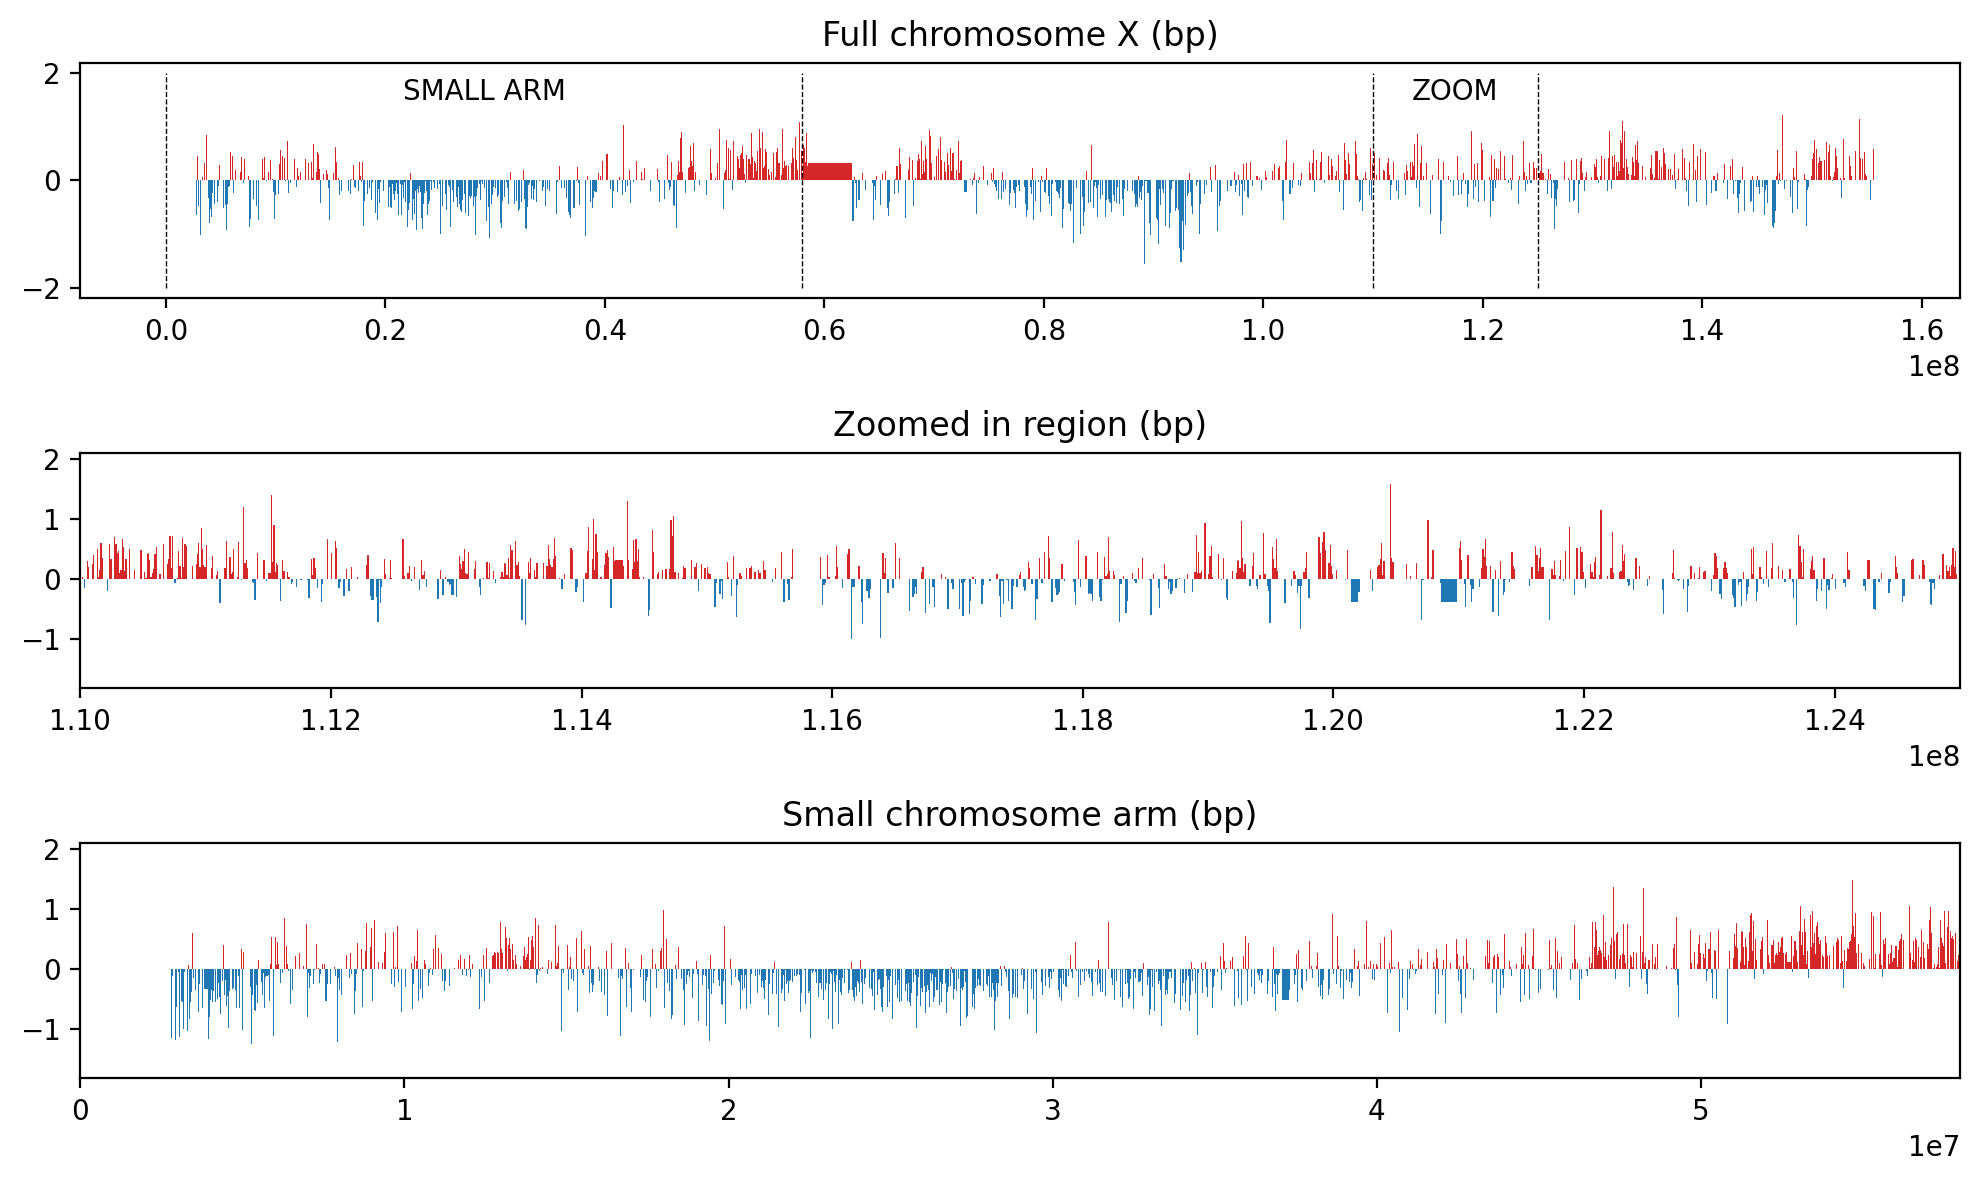

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('retina')


# Load the data
resolution = 10000

y = pd.Series(pd.read_csv(f"../data/eigs/sperm_X.eigs.{resolution}.cis.vecs.tsv", sep="\t")['E1'].values.flatten())
x = pd.Series(np.arange(0,y.shape[0])*resolution)

# Make a DataFrame object
df = pd.DataFrame({"start": x, "e1": y})
df.dropna(inplace=True)

# Plot the data

fig, ax = plt.subplots(3, figsize=(10,6))
ax[0].fill_between(df.start, df.e1, where=df.e1 > 0, color='tab:red' , ec='None', step='pre')
ax[0].fill_between(df.start, df.e1, where=df.e1 < 0, color='tab:blue', ec='None', step='pre') 
#ax[0].set_ylim(-2,2)

# Visualize the zoom and add text
begin_zoom = 1.1e08
zoom = (begin_zoom, begin_zoom + 1500*resolution)
ax[0].vlines(zoom, -2, 2, color='k', lw=0.5, ls='--')
ax[0].text(np.mean(zoom), 1.5, "ZOOM", color='k', ha='center')
ax[0].set_title("Full chromosome X (bp)")

ax[1].fill_between(df.start, df.e1, where=df.e1 > 0, color='tab:red' , ec='None', step='pre')
ax[1].fill_between(df.start, df.e1, where=df.e1 < 0, color='tab:blue', ec='None', step='pre') 

ax[1].set_xlim(zoom)
ax[1].set_title("Zoomed in region (bp)")
#ax[1].set_ylim(-2,2)

# Plot the small chromosome arm
centromere = (57984683, 69396537)
small_arm = (0, centromere[0])
ax[0].vlines(small_arm, -2, 2, color='k', lw=0.5, ls='--')
ax[0].text(np.mean(small_arm), 1.5, "SMALL ARM", color='k', ha='center')
ax[2].fill_between(df.start, df.e1, where=df.e1 > 0, color='tab:red' , ec='None', step='pre')
ax[2].fill_between(df.start, df.e1, where=df.e1 < 0, color='tab:blue', ec='None', step='pre')

ax[2].set_xlim(small_arm)
ax[2].set_title("Small chromosome arm (bp)")

plt.tight_layout()

In [2]:
# Use the zoomed region for further analysis
df_zoom = df.query(f"start >= {zoom[0]} and start <= {zoom[1]}")


# Full small arm
df_zoom = df.query(f"{small_arm[0]} <= start <= {small_arm[1]}")
df_zoom

,start,e1
278,2780000,-0.490920
279,2790000,-0.003862
280,2800000,-0.370965
281,2810000,-0.637699
282,2820000,-1.157109
...,...,...
5794,57940000,0.183996
5795,57950000,0.231840
5796,57960000,0.428673
5797,57970000,0.750196


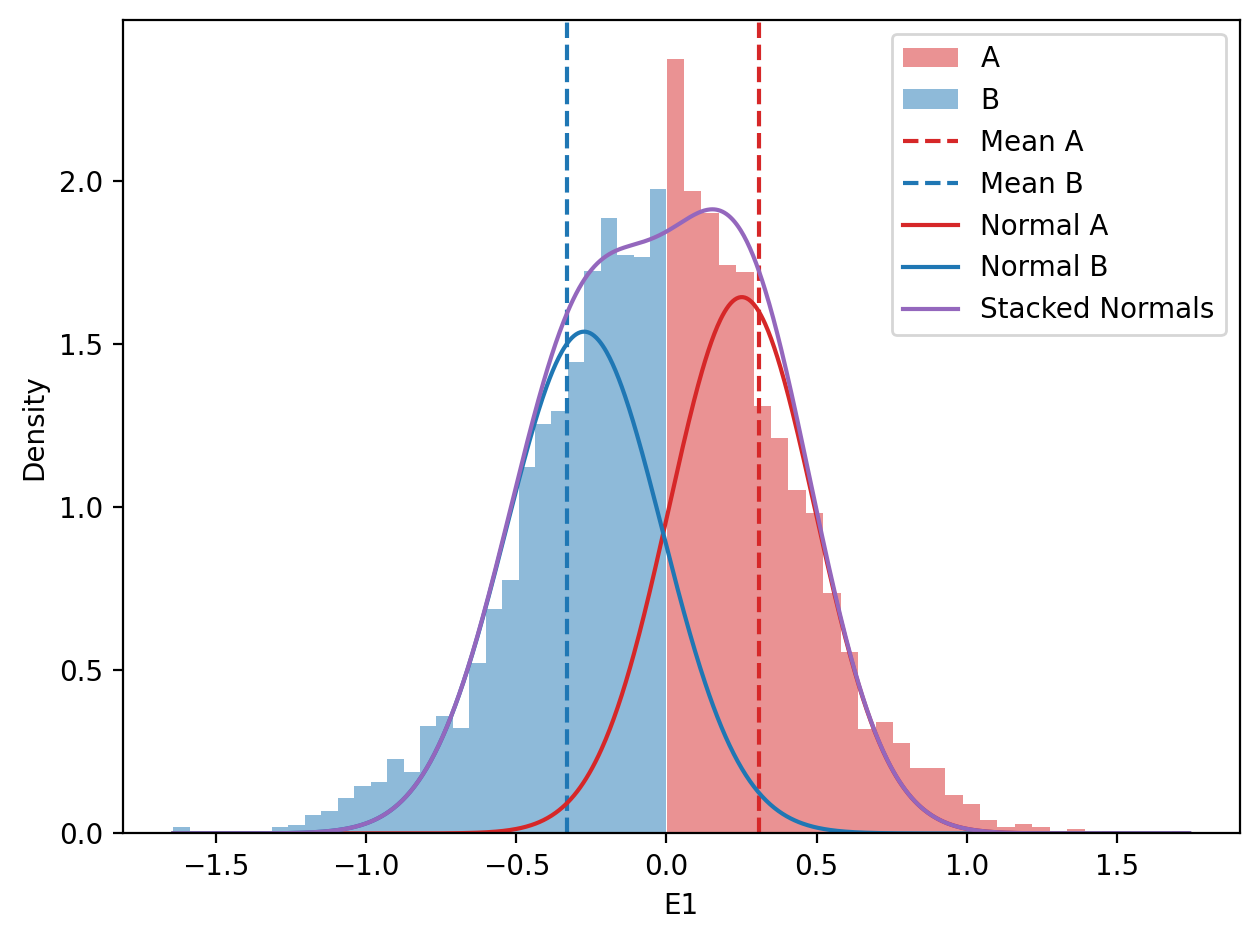

In [3]:
from scipy.stats import norm

# Histogram of distribution of E1 values (A and B)

x = df_zoom["start"].values
y = df_zoom["e1"].values

f, ax = plt.subplots()

# A compartments
ax.hist(y[y>0], bins=30, color="tab:red", alpha=0.5, label="A", density=True)
# B compartments
ax.hist(y[y<0], bins=30, color="tab:blue", alpha=0.5, label="B", density=True)
# Mean values (vline)
ax.axvline(y[y>0].mean(), color="tab:red", linestyle="--", label="Mean A")
ax.axvline(y[y<0].mean(), color="tab:blue", linestyle="--", label="Mean B")

# Plot the normal distributions
x_values = np.linspace(y.min(), y.max(), 1000)
mean_a = np.median(y[y>0])
mean_b = np.median(y[y<0])
std_a = y[y>0].std()
std_b = y[y<0].std()

ax.plot(x_values, norm.pdf(x_values, loc=mean_a, scale=std_a), color="tab:red", label="Normal A")
ax.plot(x_values, norm.pdf(x_values, loc=mean_b, scale=std_b), color="tab:blue", label="Normal B")
stacked = norm.pdf(x_values, loc=mean_a, scale=std_a) + norm.pdf(x_values, loc=mean_b, scale=std_b)
ax.plot(x_values, stacked, color="tab:purple", label="Stacked Normals")

# Final touches
plt.xlabel("E1")
plt.ylabel("Density")
plt.legend(loc='best')
plt.tight_layout()

## Model of choice

We use the model architecture decided upon in notebook `05_PyMC_bernoulli_z.ipynb`, called "N_N_HN". 

### Model architecture

We assume that we can draw the eigenvectors from two distributions, resulting in a mixture of two distributions. The `components` of this distribution are

- `components = T`: The mixture components for eigenvectors are assumed to be from a StudentT distribution with `nu=10`. Is is a bit more heavy-tailed than a normal distribution with the same mean, meaning we will allow for larger deviations from the mean.

The bins are assumed to be dependent on the state of the previous bin, so a step size, `eps`, is modeled with Random Walk.

- `eps = N`: the step size is drawn from a Normal distribution with `mu=0` and `sigma=1.0`

The walk is modeled as the cumulative sum of steps `pt.cumsum(eps * grw_sigma)`, where

- `grw_sigma = HN`: the standard deviation of the step size is drawn from a HalfNormal distribution with `sigma=0.05`.

Then, it is forced through a sigmoid to ensure values between 0 and 1, and finally, the latent compartment 'state' is inferred by making a Bernoulli draw from the sigmoid output.

### Model factory function

Define the model builder, and import the configuration from file. 

In [4]:
import pymc as pm 
import pytensor.tensor as pt

def build_z_model_from_config(df, cfg):
    """
    Build a PyMC model based on the provided configuration dictionary.
    """
    e1 = df.e1.values 
    mean_negative = df.e1[df.e1 < 0].mean()
    mean_positive = df.e1[df.e1 > 0].mean()
    cfg['mu_mu'] = np.array([mean_negative, mean_positive])
    cfg['mu_sigma'] = np.array([df.e1[df.e1 < 0].std(), df.e1[df.e1 > 0].std()])
    
    with pm.Model(coords={"pos": df.index.values, "label": ["B", "A"]}) as model:
        # e1 = pm.Data("e1", df.e1.values, dims="pos")


        mu = pm.Normal("mu", mu=cfg['mu_mu'], sigma=cfg['mu_sigma'],
                       transform=pm.distributions.transforms.ordered, dims="label")
        sigma = pm.HalfNormal("sigma", sigma=cfg['sigma'], dims="label")

        # components: Normal or StudentT
        if cfg['comp_dist'] == "Normal":
            components = pm.Normal.dist(mu=mu, sigma=sigma, shape=2)
        else:
            components = pm.StudentT.dist(mu=mu, sigma=sigma, **cfg['comp_kwargs'], shape=2)

        # grw_sigma: HalfNormal or HalfStudentT
        if cfg['grw_sigma_dist'] == "HalfNormal":
            grw_sigma = pm.HalfNormal("grw_sigma", **cfg['grw_sigma_kwargs'])
        else:
            grw_sigma = pm.HalfStudentT("grw_sigma", **cfg['grw_sigma_kwargs'])

        # eps: Normal or StudentT
        if cfg['eps_dist'] == "Normal":
            eps = pm.Normal("eps", dims="pos", mu=0.0, sigma=1.0)
        else:
            eps = pm.StudentT("eps", dims="pos", mu=0.0, sigma=1.0, nu=cfg['eps_kwargs']['nu'])

        logit_w = pm.Deterministic("logit_w", pt.cumsum(eps*grw_sigma), dims="pos")
        w = pm.Deterministic("w", pm.math.sigmoid(logit_w), dims="pos")

        # Make a latent variable for the mixture model
        z = pm.Bernoulli("z", p=w, dims="pos")


        y_hat = pm.Mixture("y_hat", w=pt.stack([1-z,z], axis=1), comp_dists=components,
                           observed=e1, dims='pos')

    return model

def build_mix_model_from_config(df, cfg):
    """
    Build a PyMC model based on the provided configuration dictionary.
    """
    e1 = df.e1.values 
    mean_negative = df.e1[df.e1 < 0].mean()
    mean_positive = df.e1[df.e1 > 0].mean()
    cfg['mu_mu'] = np.array([mean_negative, mean_positive])
    cfg['mu_sigma'] = np.array([df.e1[df.e1 < 0].std(), df.e1[df.e1 > 0].std()])
    
    with pm.Model(coords={"pos": df.index.values, "label": ["B", "A"]}) as model:
        # e1 = pm.Data("e1", df.e1.values, dims="pos")


        mu = pm.Normal("mu", mu=cfg['mu_mu'], sigma=cfg['mu_sigma'],
                       transform=pm.distributions.transforms.ordered, dims="label")
        sigma = pm.HalfNormal("sigma", sigma=cfg['sigma'], dims="label")

        # components: Normal or StudentT
        if cfg['comp_dist'] == "Normal":
            components = pm.Normal.dist(mu=mu, sigma=sigma, shape=2)
        else:
            components = pm.StudentT.dist(mu=mu, sigma=sigma, **cfg['comp_kwargs'], shape=2)

        # grw_sigma: HalfNormal or HalfStudentT
        if cfg['grw_sigma_dist'] == "HalfNormal":
            grw_sigma = pm.HalfNormal("grw_sigma", **cfg['grw_sigma_kwargs'])
        else:
            grw_sigma = pm.HalfStudentT("grw_sigma", **cfg['grw_sigma_kwargs'])

        # eps: Normal or StudentT
        if cfg['eps_dist'] == "Normal":
            eps = pm.Normal("eps", dims="pos", mu=0.0, sigma=1.0)
        else:
            eps = pm.StudentT("eps", dims="pos", mu=0.0, sigma=1.0, nu=cfg['eps_kwargs']['nu'])

        logit_w = pm.Deterministic("logit_w", pt.cumsum(eps*grw_sigma), dims="pos")
        w = pm.Deterministic("w", pm.math.sigmoid(logit_w), dims="pos")


        y_hat = pm.Mixture("y_hat", w=pt.stack([1-w,w], axis=1), comp_dists=components,
                           observed=e1, dims='pos')

    return model

In [5]:
import json

with open("../results/model_grid.json", "r") as f:
    config_list = json.load(f)

configs = {cfg['name']: cfg for cfg in config_list}

name = "N_N_HN"

config = configs[name]
config['grw_sigma_kwargs'] = {'sigma': 0.005}
config

{'name': 'N_N_HN',
 'comp_dist': 'Normal',
 'comp_kwargs': {},
 'eps_dist': 'Normal',
 'eps_kwargs': {'mu': 0.0, 'sigma': 1.0},
 'grw_sigma_dist': 'HalfNormal',
 'grw_sigma_kwargs': {'sigma': 0.005},
 'mu_mu': [-0.5, 0.5],
 'mu_sigma': 0.3,
 'sigma': 0.3}

graph TD
%% Nodes:
eps([eps ~ Normal])
eps@{ shape: rounded }
grw_sigma([grw_sigma ~ Halfnormal])
grw_sigma@{ shape: rounded }
logit_w([logit_w ~ Deterministic])
logit_w@{ shape: rect }
mu([mu ~ Normal])
mu@{ shape: rounded }
sigma([sigma ~ Halfnormal])
sigma@{ shape: rounded }
w([w ~ Deterministic])
w@{ shape: rect }
y_hat([y_hat ~ Mixture])
y_hat@{ shape: rounded }
style y_hat fill:#757575
z([z ~ Bernoulli])
z@{ shape: rounded }

%% Edges:
eps --> logit_w
grw_sigma --> logit_w
logit_w --> w
mu --> y_hat
sigma --> y_hat
z --> y_hat
w --> z

%% Plates:
subgraph "label (2)"
    mu
    sigma
end
subgraph "pos (5376)"
    w
    logit_w
    y_hat
    eps
    z
end


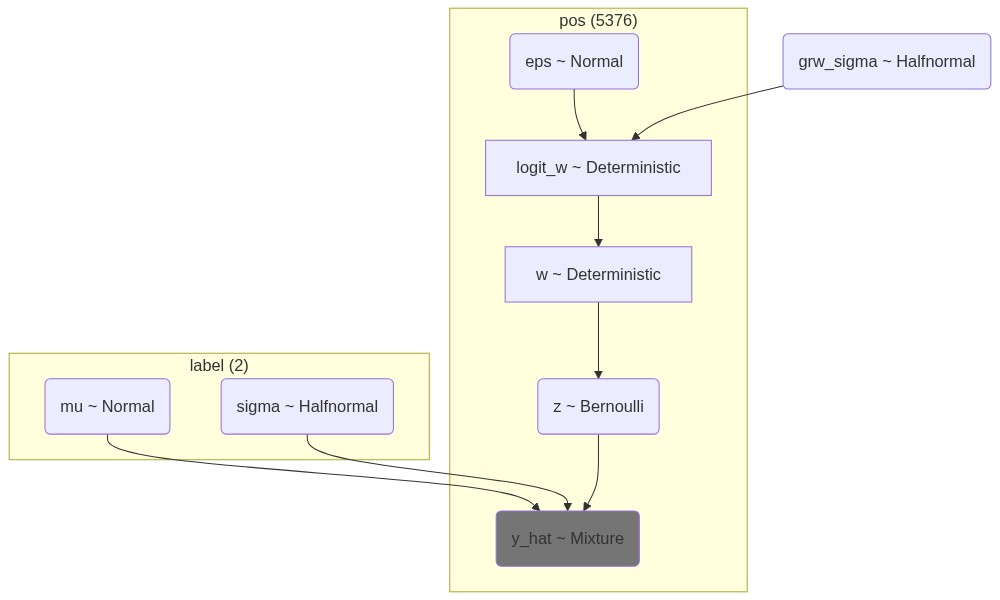

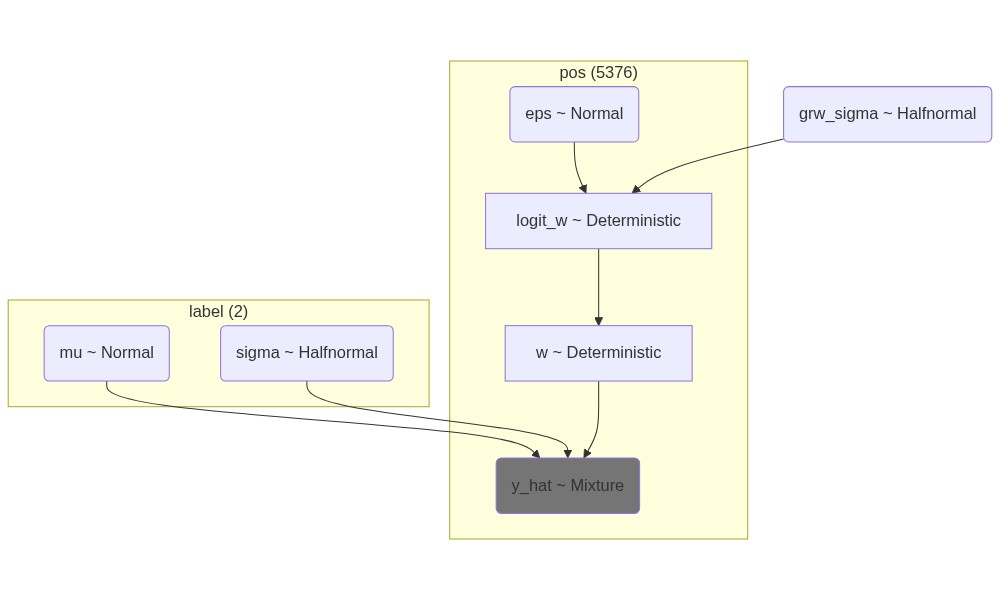

In [6]:
import pymc as pm
from mermaid import Mermaid, Graph
from IPython.display import Image

# Build the model
model_z = build_z_model_from_config(df_zoom, config)
model_w = build_mix_model_from_config(df_zoom, config)

# Visualize the model

mermaid_z = Graph("Hard assignment", pm.model_to_mermaid(model_z))
mermaid_w = Graph("Soft assignment", pm.model_to_mermaid(model_w))

render_z = Mermaid(mermaid_z, width=1000, height=600)
render_w = Mermaid(mermaid_w, width=1000, height=600, )

print(mermaid_z.script)

# Display the models
display(Image(render_z.img_response.content, width=1000, height=600, retina=True))
display(Image(render_w.img_response.content, width=1000, height=600, retina=True))


In [7]:
with model_z:
    idata_z = pm.sample(draws=1000, tune=1000, chains=7, cores=7, progressbar=False)
    pm.compute_log_likelihood(idata_z, progressbar=False)
    prior_predictive_z = pm.sample_prior_predictive(1000)
    posterior_predictive_z = pm.sample_posterior_predictive(idata_z, progressbar=False)
idata_z.extend(prior_predictive_z)
idata_z.extend(posterior_predictive_z)
    
with model_w:
    idata_w = pm.sample(draws=1000, tune=1000, chains=7, cores=7, progressbar=False)
    pm.compute_log_likelihood(idata_w, progressbar=False)
    prior_predictive_w = pm.sample_prior_predictive(1000)
    posterior_predictive_w = pm.sample_posterior_predictive(idata_w, progressbar=False)
idata_w.extend(prior_predictive_w)
idata_w.extend(posterior_predictive_w)

Multiprocess sampling (7 chains in 7 jobs)


CompoundStep


>NUTS: [mu, sigma, grw_sigma, eps]


>BinaryGibbsMetropolis: [z]


Sampling 7 chains for 1_000 tune and 1_000 draw iterations (7_000 + 7_000 draws total) took 6547 seconds.


...

Multiprocess sampling (7 chains in 7 jobs)


NUTS: [mu, sigma, grw_sigma, eps]


Sampling 7 chains for 1_000 tune and 1_000 draw iterations (7_000 + 7_000 draws total) took 178 seconds.


Sampling: [eps, grw_sigma, mu, sigma, y_hat]


Sampling: [y_hat]


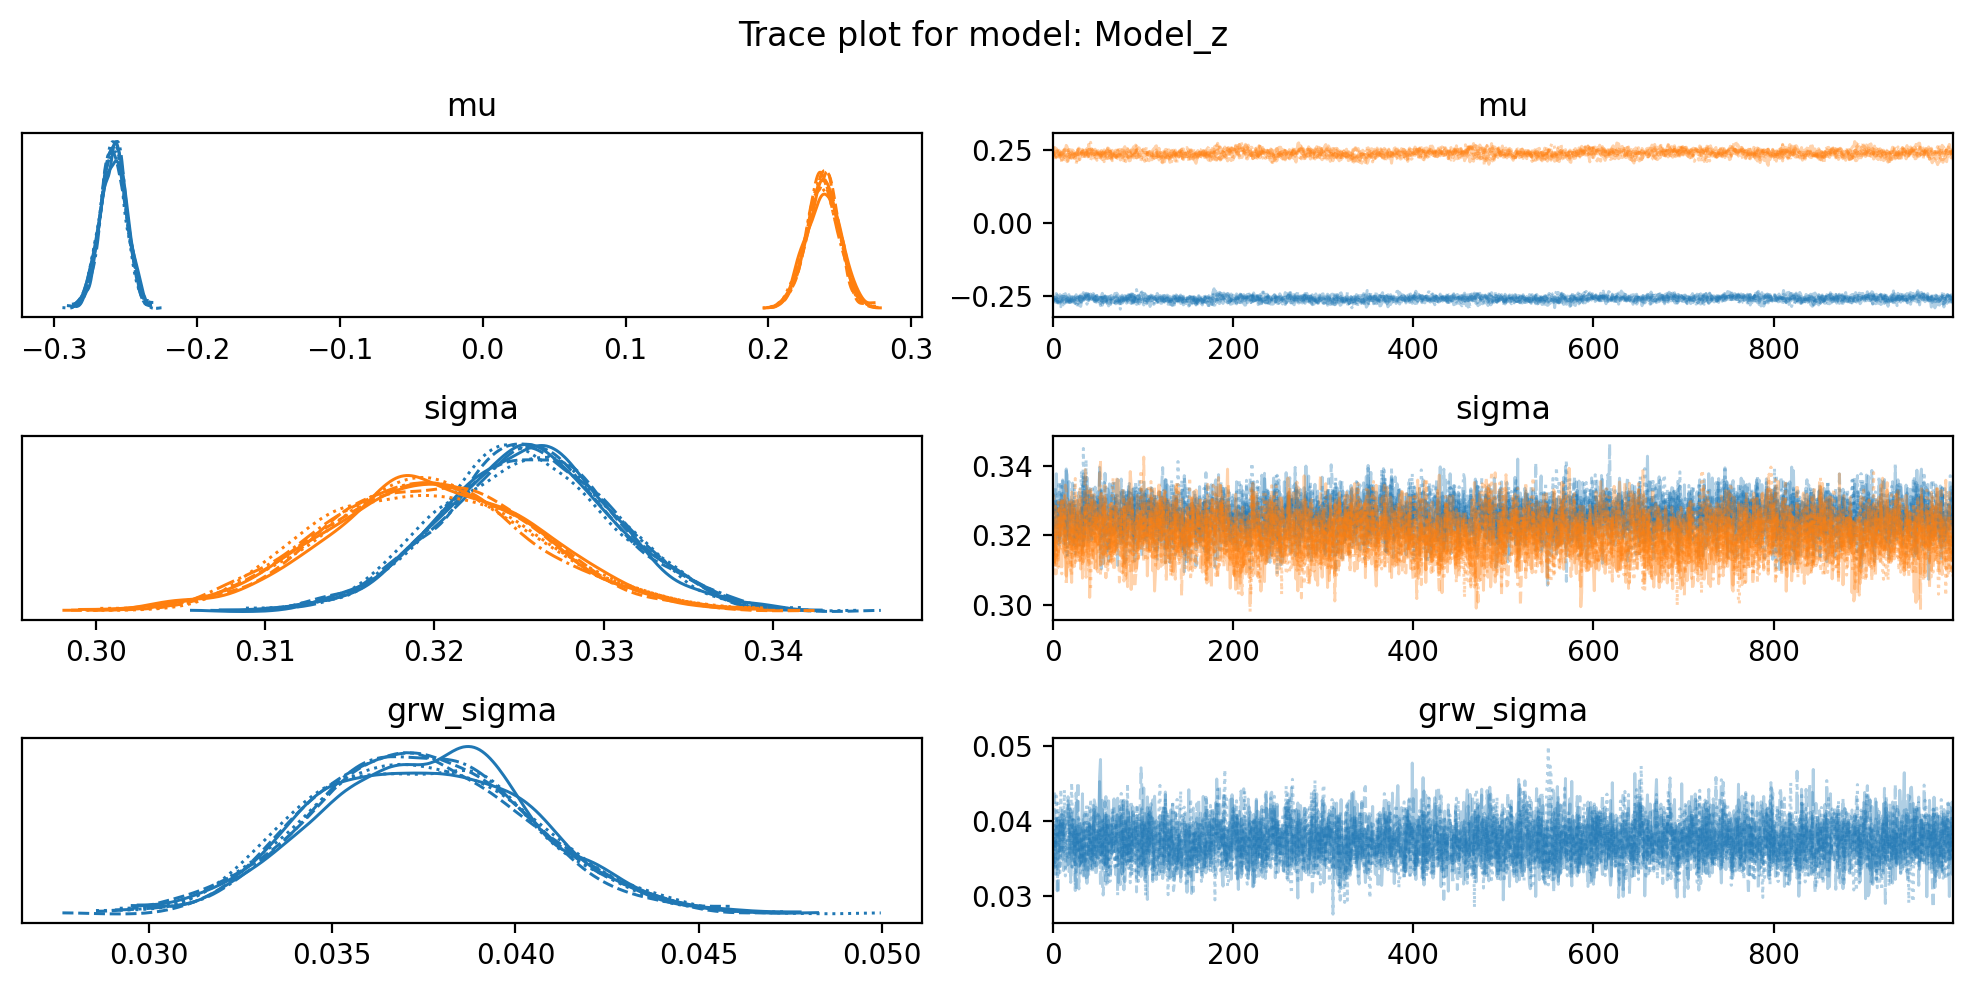

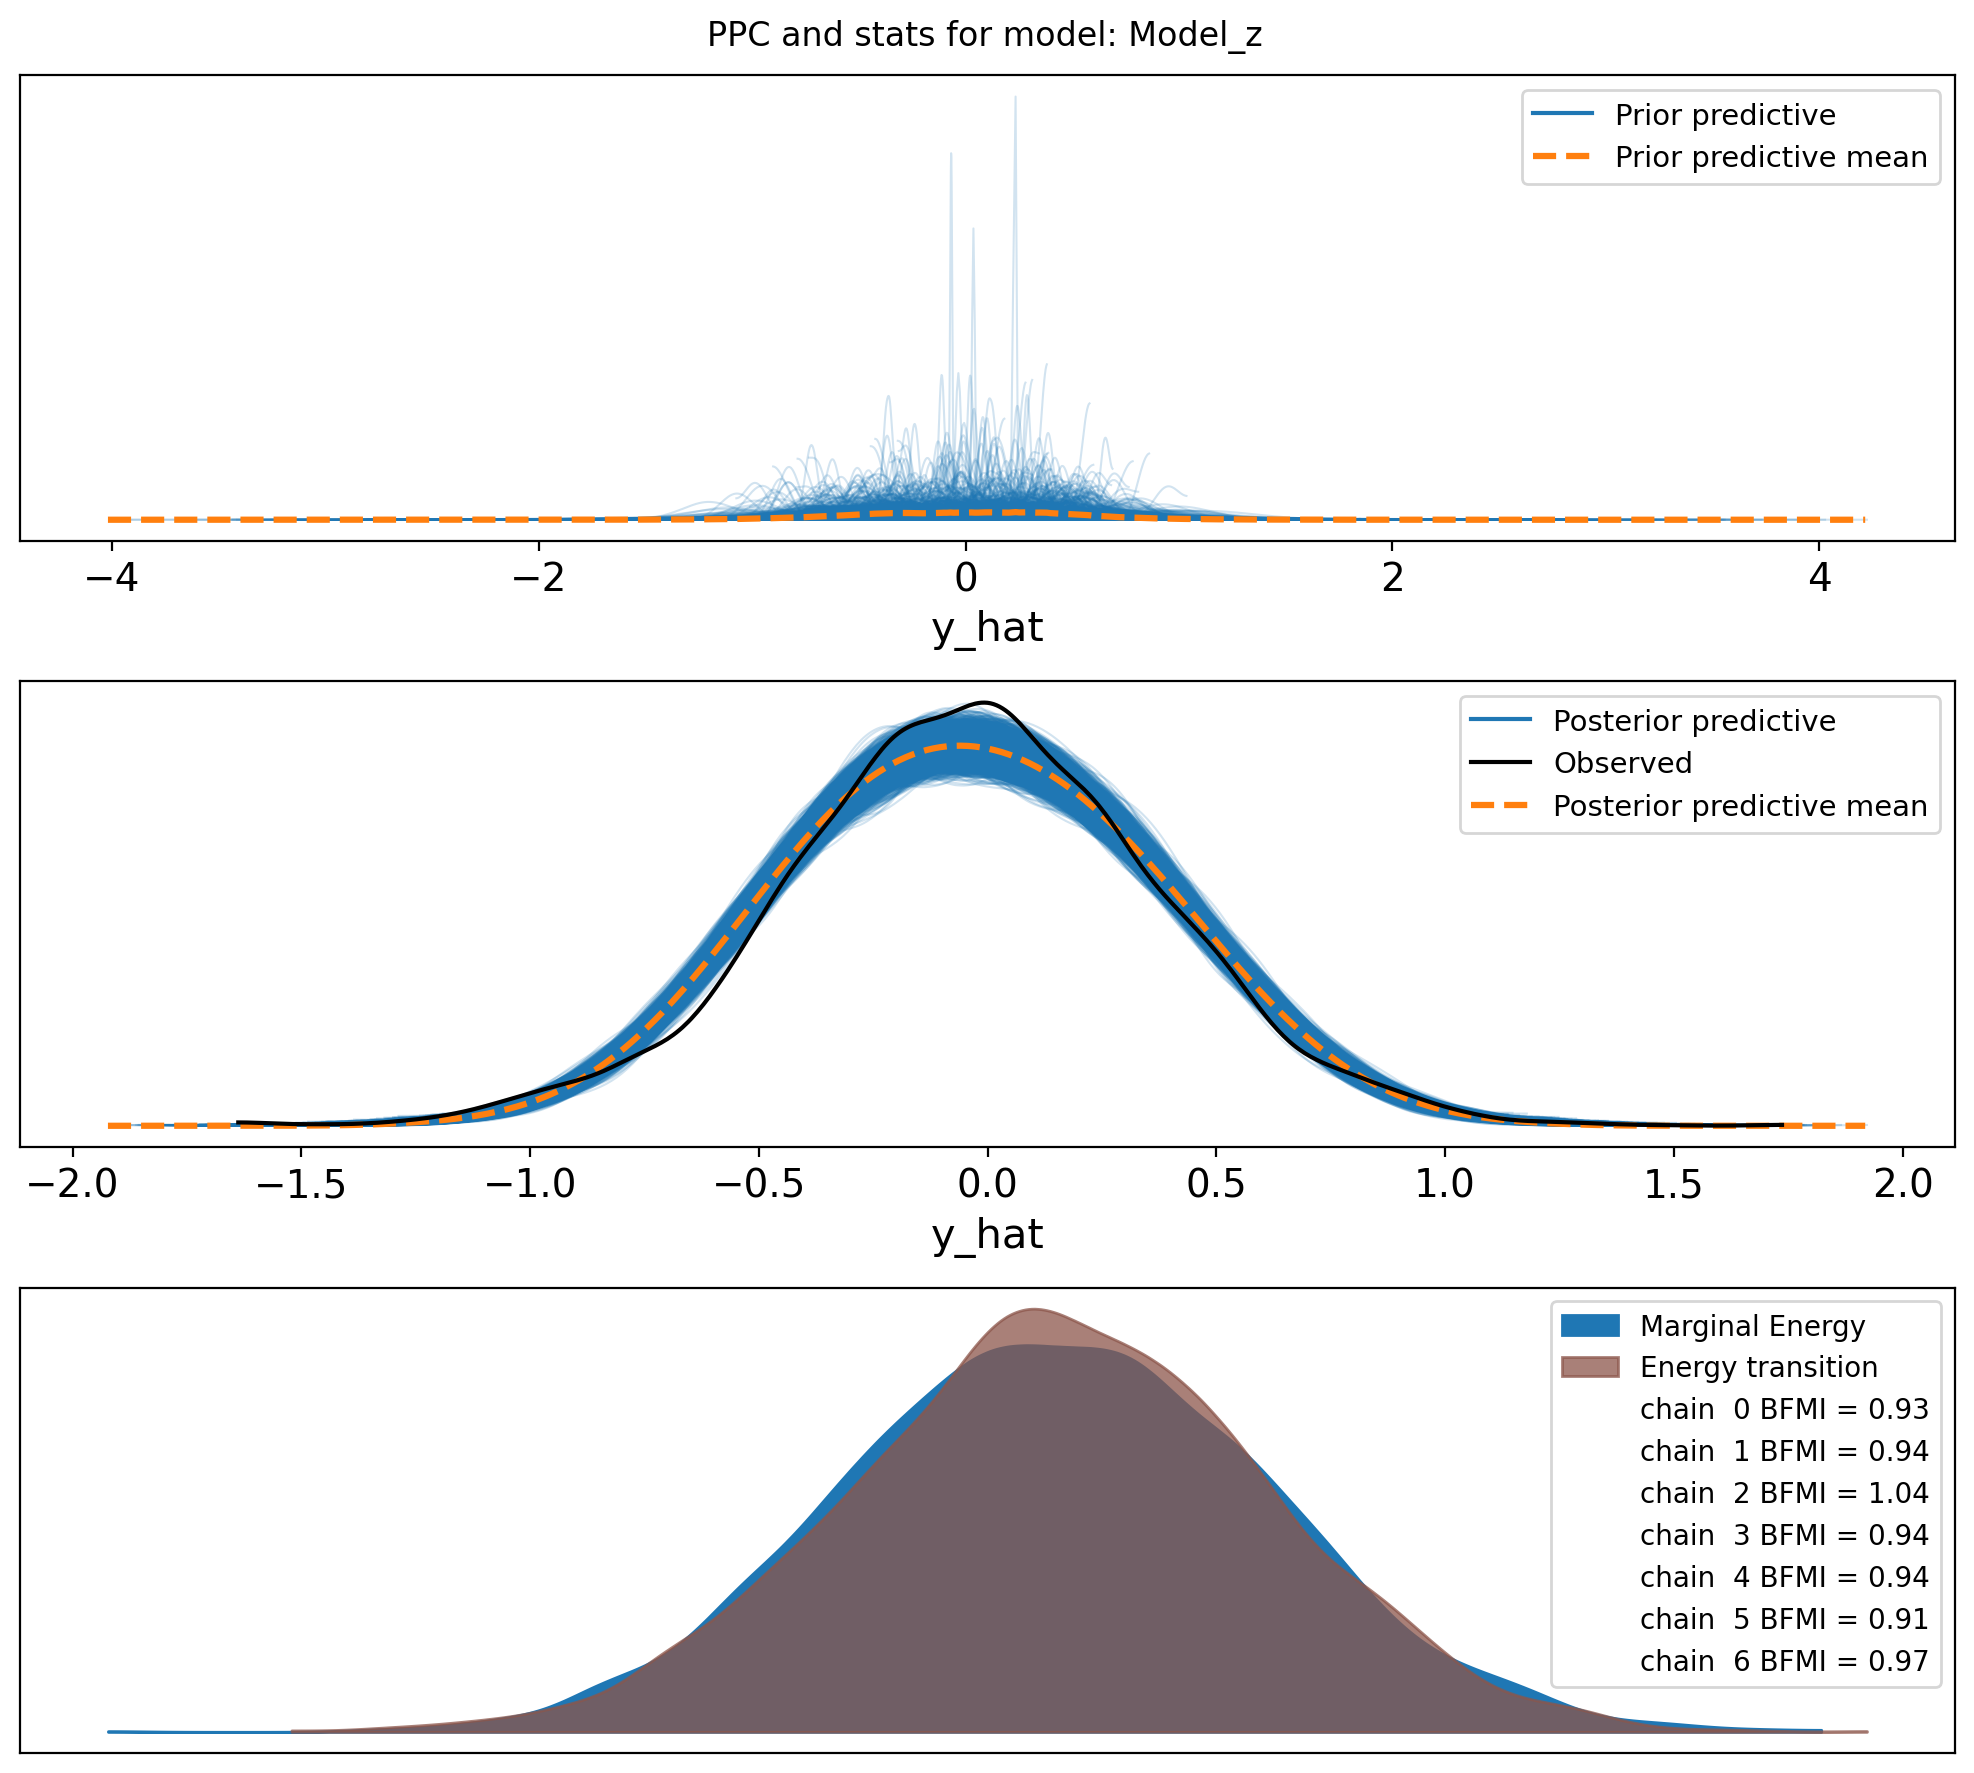

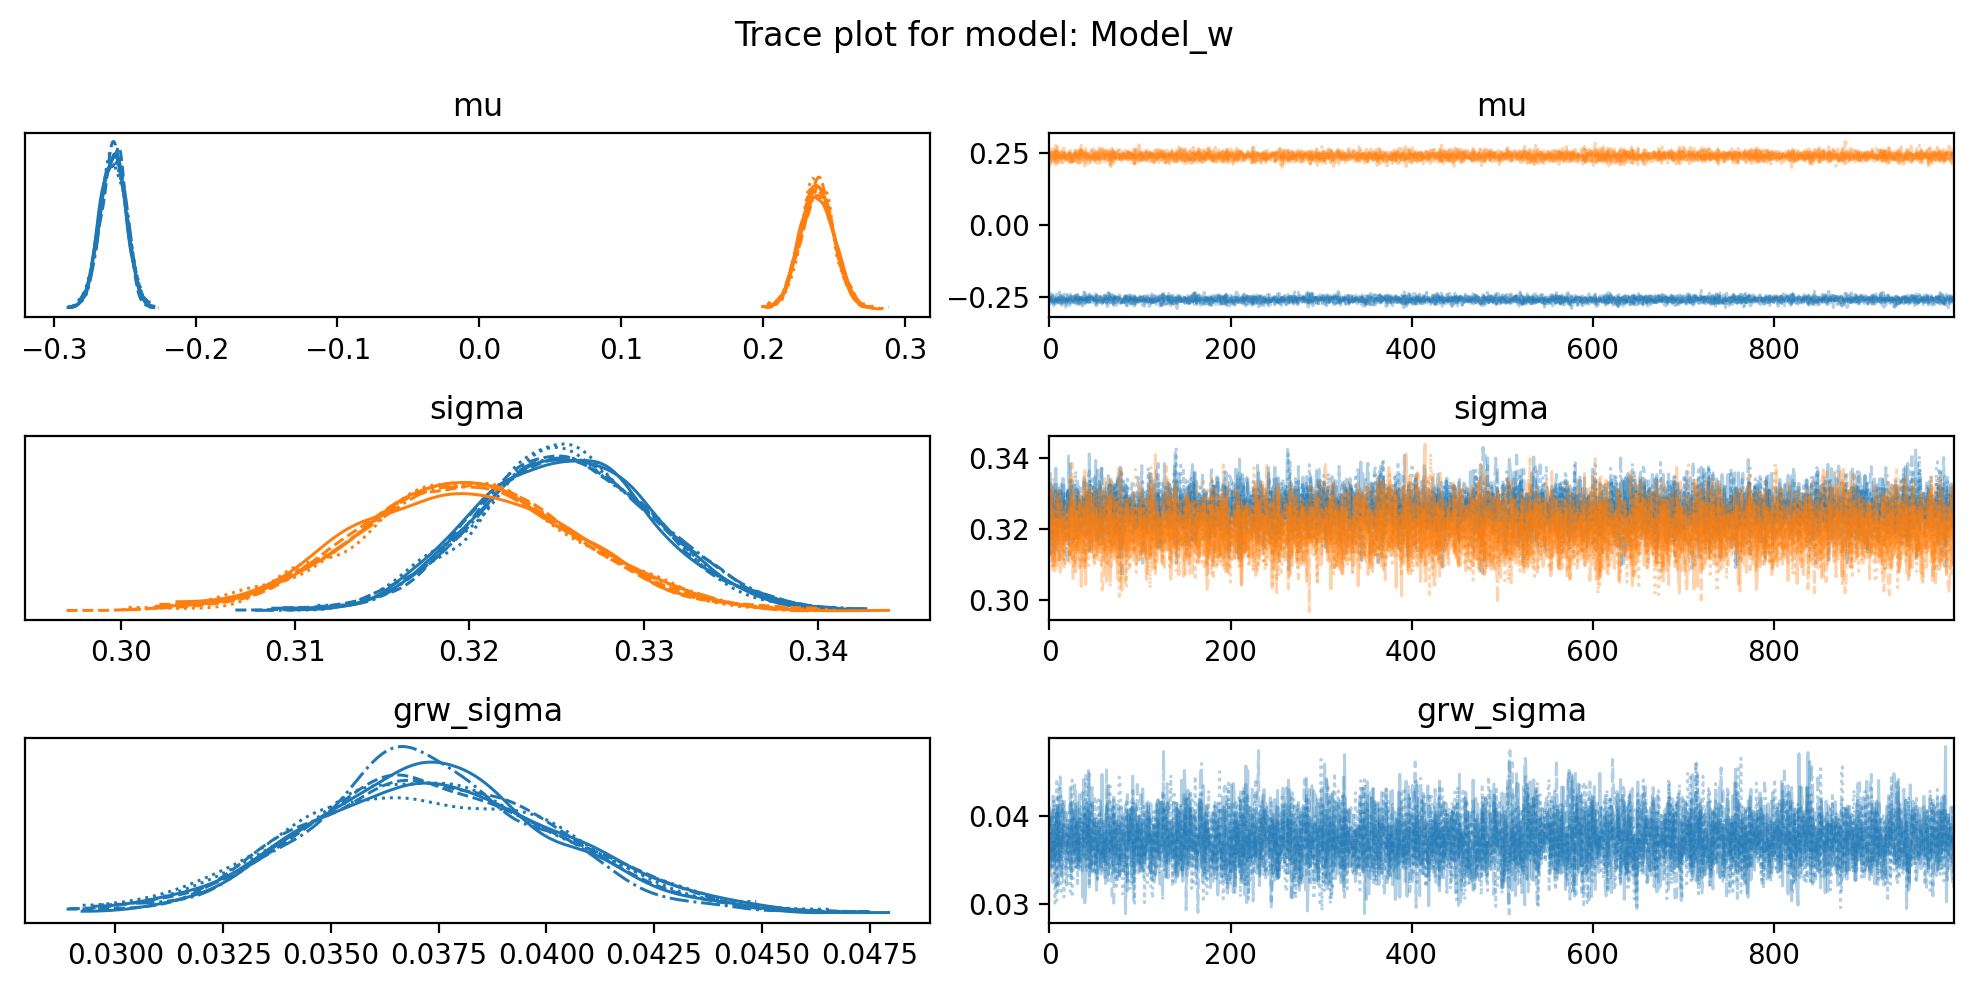

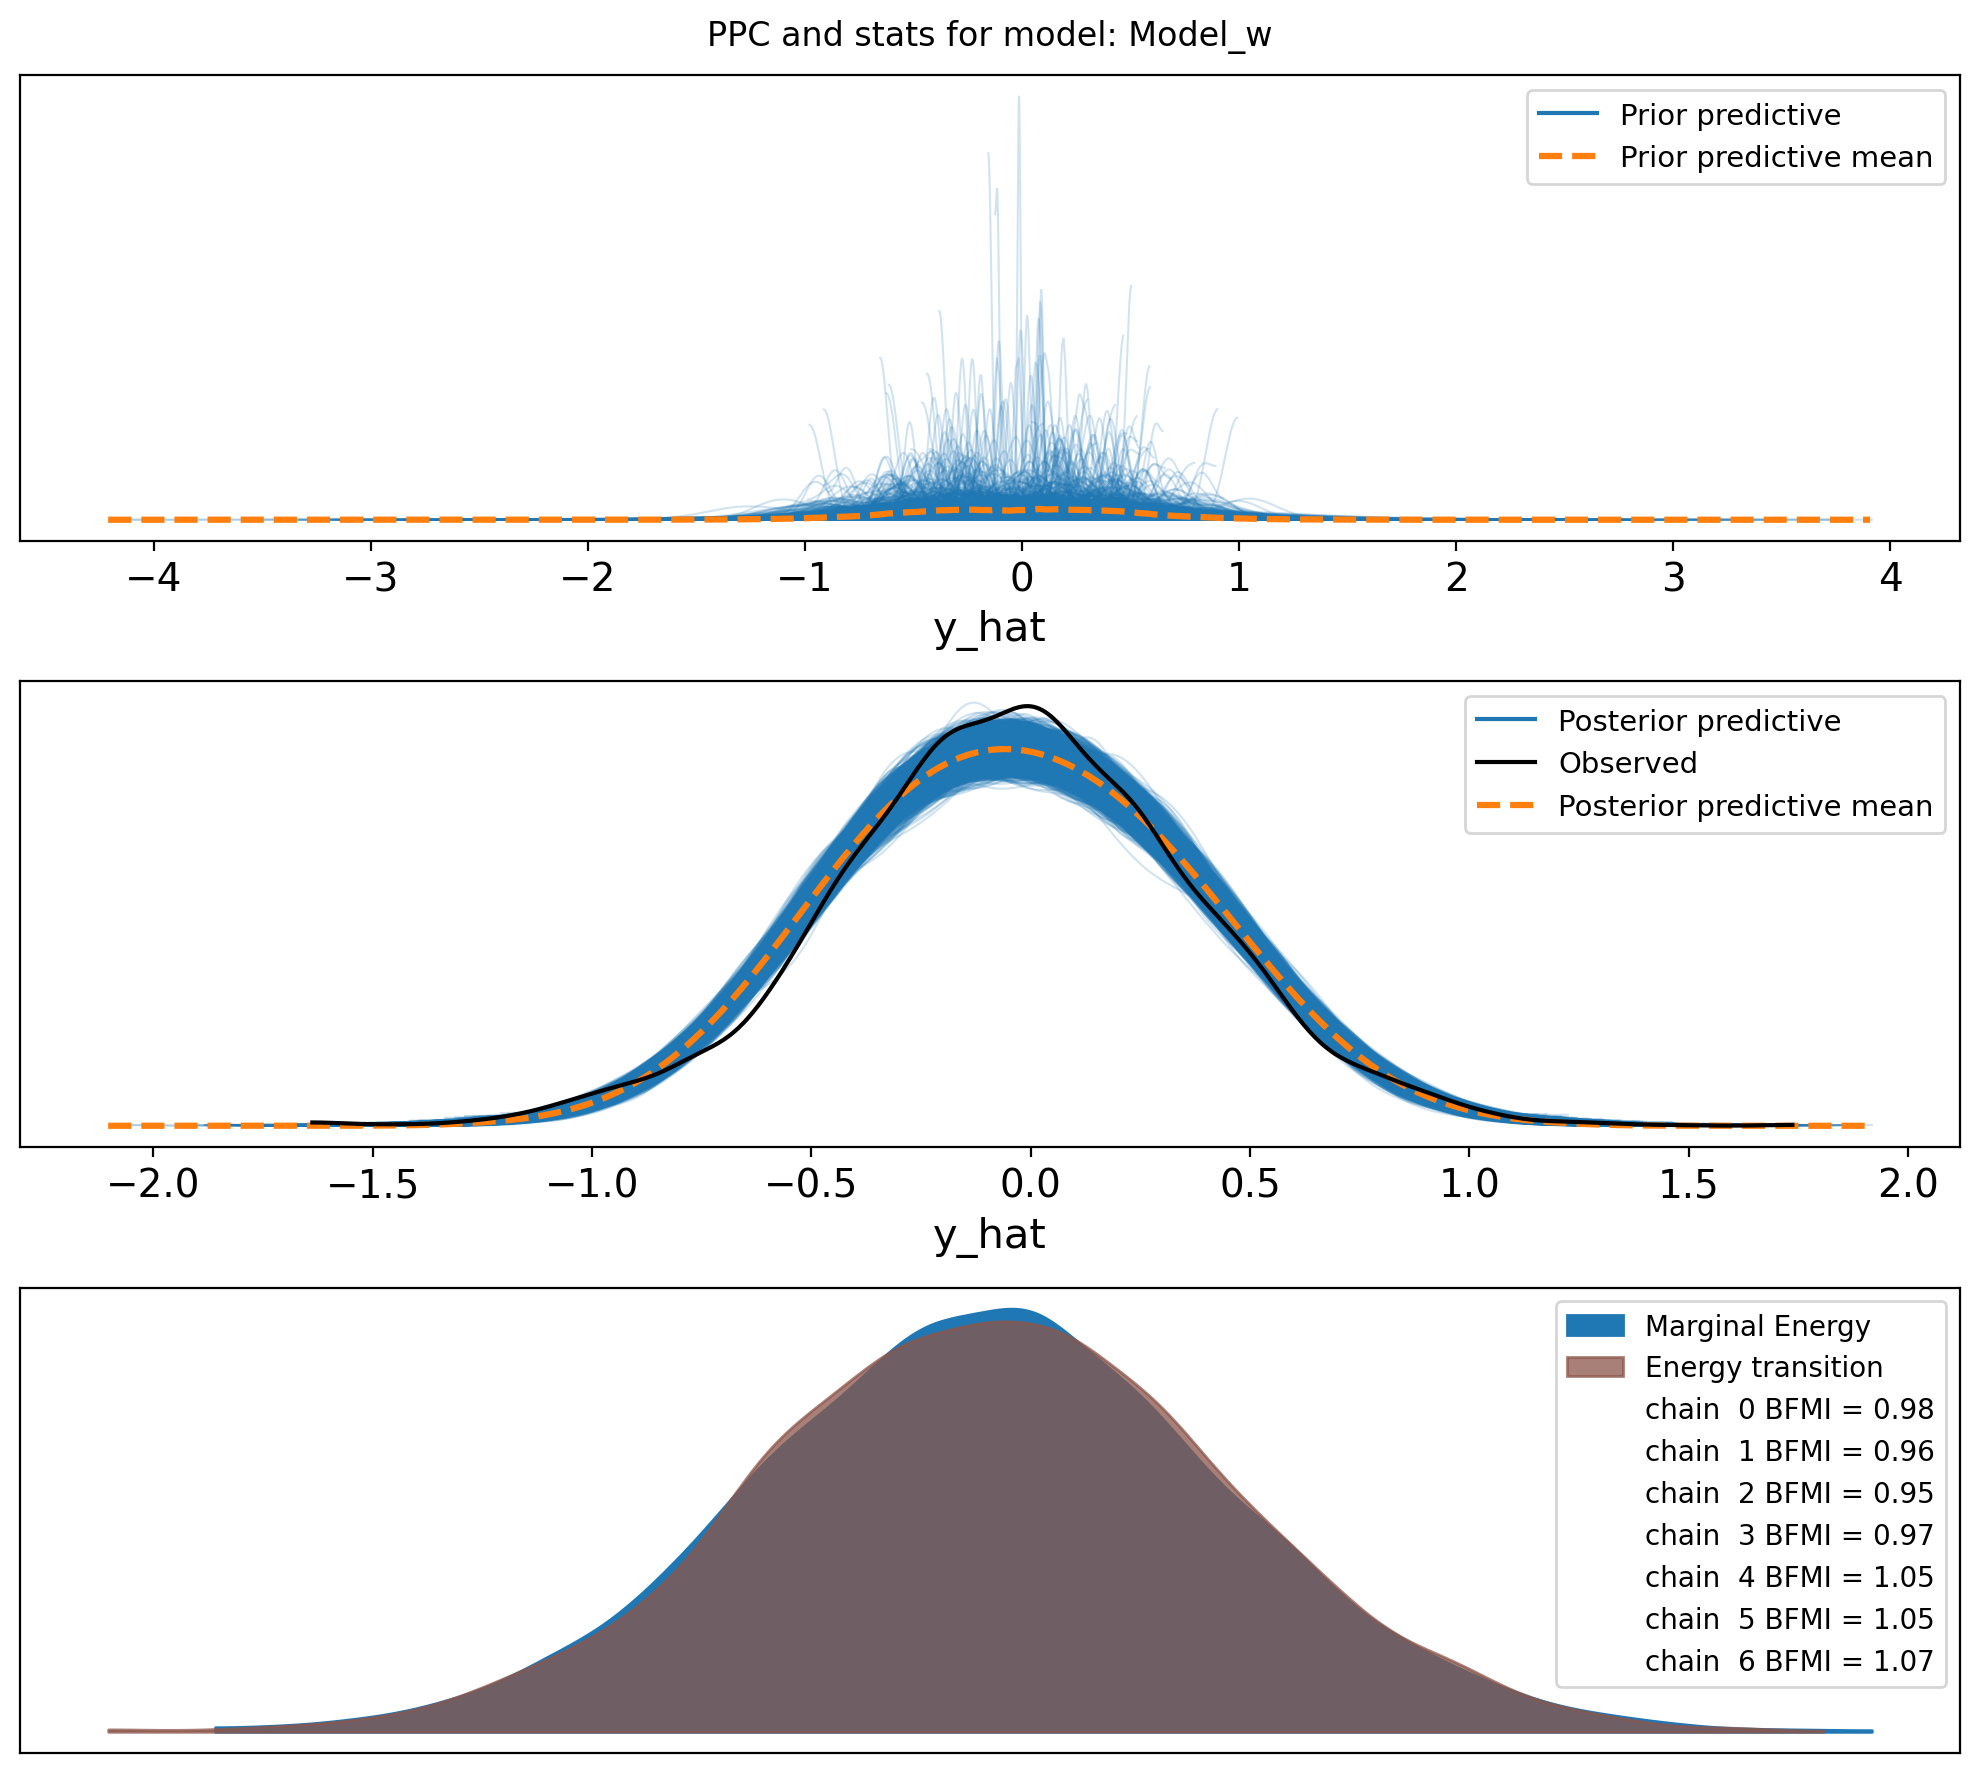

In [8]:
import arviz as az

for name,idata in {'Model_z': idata_z, 'Model_w': idata_w}.items():
    f, axs = plt.subplots(3, 2, figsize=(10, 5))

    az.plot_trace(idata, var_names=["mu", "sigma", "grw_sigma"], compact=True, axes = axs)
    plt.suptitle(f"Trace plot for model: {name}")
    plt.tight_layout()



    f,axs = plt.subplots(3, figsize=(10, 9))
    axs = axs.flatten()

    az.plot_ppc(idata, var_names=["y_hat"], group="prior", ax=axs[0])
    az.plot_ppc(idata, var_names=["y_hat"], ax=axs[1])
    az.plot_energy(idata, ax = axs[2])
    plt.suptitle(f"PPC and stats for model: {name}")
    plt.tight_layout()

~~So, it looks like the data may not come from two distrinct distributions for E1 values in this sample. I am confused. I guess we go back to the drawing board.~~

For some reason, the distributions of E1 values in the `sperm_x` dataset do not look like two distinct distributions, in opposite to the macaque data, although both are from sperm cells. I do not think it has anything to do with the sex chromosome being only X. 

In [9]:
## Saving the trace for later use
import os.path as op
import os
import cloudpickle

# Save the traces to file (netcdf)

dir = "../results"

name_z = "07_hi_res_z"
name_w = "07_hi_res_w"
# Save the model.Model as a cloudpickle.dumps
os.makedirs(op.join(dir, "models"), exist_ok=True)

model_z_path = op.join(dir, "models", f"{name_z}_model.pkl")
model_w_path = op.join(dir, "models", f"{name_w}_model.pkl")
with open(model_z_path, "wb") as f:
    cloudpickle.dump(model_z, f)

with open(model_w_path, "wb") as f:
    cloudpickle.dump(model_w, f)


# Save the trace as a netcdf file
trace_z_path = op.join(dir, "traces", f"{name_z}_trace.nc")
trace_w_path = op.join(dir, "traces", f"{name_w}_trace.nc")
os.makedirs(op.dirname(trace_z_path), exist_ok=True)
os.makedirs(op.dirname(trace_w_path), exist_ok=True)


az.to_netcdf(idata_z, trace_z_path)
az.to_netcdf(idata_w, trace_w_path)


'../results/traces/07_hi_res_w_trace.nc'